TEST 5: PARAMETER SWEEP - FINDING THE LORENTZ INVARIANCE SWEET SPOT
Mapping the Emergent Dimension across XI (Melting) and MAX_R (Locality)

Running Sweep: T=20, Grid=25x25
XI range: [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
MAX_R range: [2, 3, 4, 5]
This will take ~2-3 minutes...

  XI=0.2, R=2 -> D = 2.534
  XI=0.2, R=3 -> D = 2.556
  XI=0.2, R=4 -> D = 2.519
  XI=0.2, R=5 -> D = 2.524
  XI=0.3, R=2 -> D = 2.531
  XI=0.3, R=3 -> D = 2.493
  XI=0.3, R=4 -> D = 2.506
  XI=0.3, R=5 -> D = 2.526
  XI=0.4, R=2 -> D = 2.501
  XI=0.4, R=3 -> D = 2.552
  XI=0.4, R=4 -> D = 2.533
  XI=0.4, R=5 -> D = 2.498
  XI=0.5, R=2 -> D = 2.475
  XI=0.5, R=3 -> D = 2.512
  XI=0.5, R=4 -> D = 2.495
  XI=0.5, R=5 -> D = 2.484
  XI=0.6, R=2 -> D = 2.446
  XI=0.6, R=3 -> D = 2.531
  XI=0.6, R=4 -> D = 2.491
  XI=0.6, R=5 -> D = 2.493
  XI=0.7, R=2 -> D = 2.483
  XI=0.7, R=3 -> D = 2.458
  XI=0.7, R=4 -> D = 2.419
  XI=0.7, R=5 -> D = 2.433
  XI=0.8, R=2 -> D = 2.486
  XI=0.8, R=3 -> D = 2.396
  XI=0.8, R=4 ->

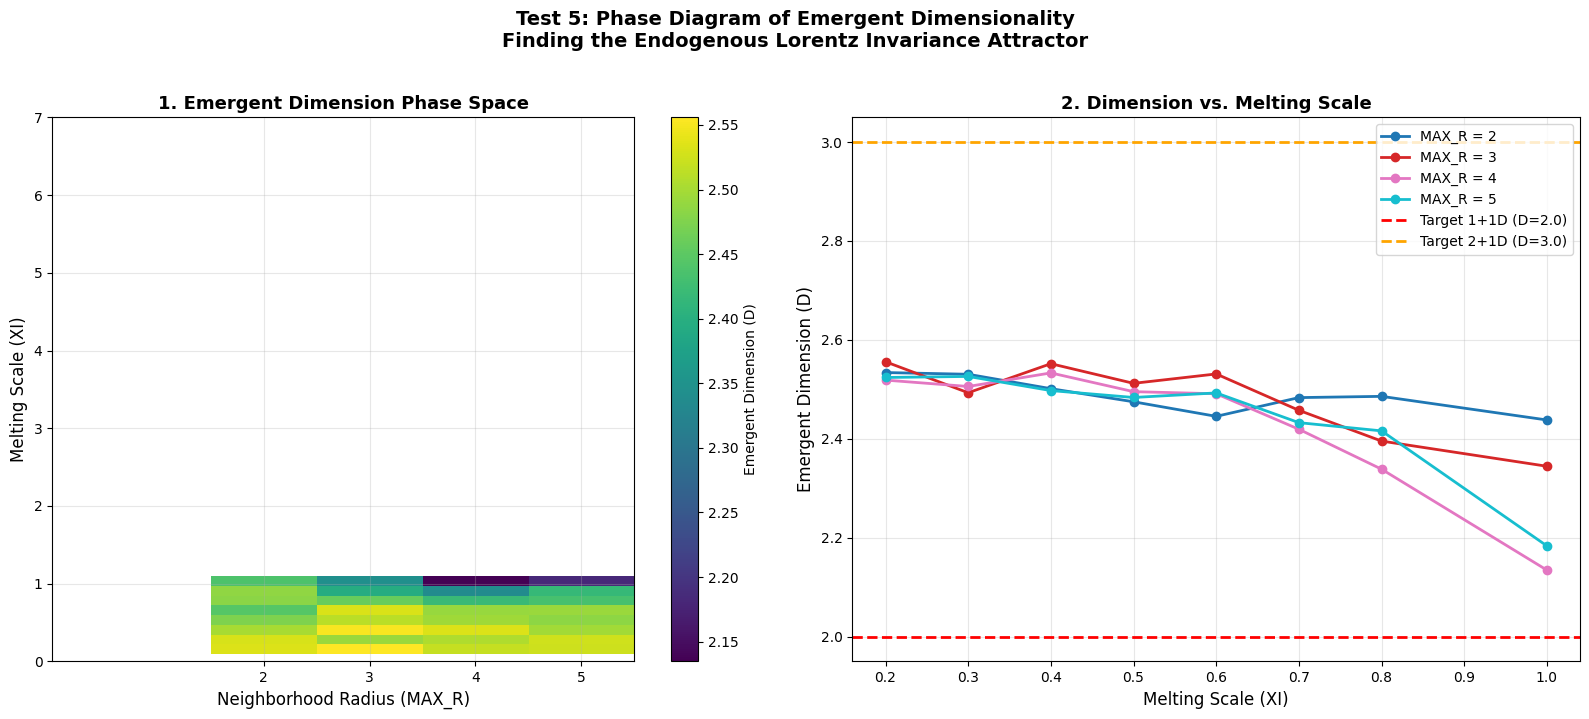


TEST 5 SWEEP VERDICT
Closest match to 1+1D Target (D=2.0):
  -> XI = 1.0, MAX_R = 4
  -> Achieved D = 2.135

INSTRUCTIONS:
1. Look at the Heatmap (Panel 1). The red contour line shows where D=2.0.
2. Look at the Line Plot (Panel 2). Find where the lines cross the red dashed line.
3. Take those optimal XI and MAX_R values and run the full-scale simulation (T=40, Grid=60).


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TEST 5: PARAMETER SWEEP - FINDING THE LORENTZ INVARIANCE SWEET SPOT")
print("Mapping the Emergent Dimension across XI (Melting) and MAX_R (Locality)")
print("=" * 80)

# =============================================================================
# 1. FINITIST ENGINE (Optimized for Sweep)
# =============================================================================
def generate_melting_causal_set(T, size, xi, max_r, p_min):
    """Generates a causal set with bounded locality."""
    longest_path = np.full((T, size, size), -1, dtype=np.int32)
    longest_path[0, size//2, size//2] = 0

    for t in range(1, T):
        for x in range(size):
            for y in range(size):
                max_parent_path = -1

                x_min = max(0, x - max_r)
                x_max = min(size, x + max_r + 1)
                y_min = max(0, y - max_r)
                y_max = min(size, y + max_r + 1)

                # Vectorized distance calculation for the neighborhood
                px_arr = np.arange(x_min, x_max)
                py_arr = np.arange(y_min, y_max)
                PX, PY = np.meshgrid(px_arr, py_arr)

                dist = np.sqrt((x - PX)**2 + (y - PY)**2)

                # Get parent paths from previous time step
                parent_paths = longest_path[t-1, y_min:y_max, x_min:x_max]
                valid_mask = parent_paths != -1

                if np.any(valid_mask):
                    valid_dist = dist[valid_mask]
                    valid_paths = parent_paths[valid_mask]

                    # Calculate probabilities
                    probs = np.exp(-valid_dist / xi)
                    probs[valid_dist < 1.5] = np.maximum(probs[valid_dist < 1.5], p_min)

                    # Stochastic connection
                    connections = np.random.rand(len(probs)) < probs

                    if np.any(connections):
                        max_parent_path = np.max(valid_paths[connections])

                if max_parent_path != -1:
                    longest_path[t, x, y] = max_parent_path + 1

    return longest_path

def measure_dimension(longest_path):
    """Measures dimension via Volume vs Longest Chain scaling."""
    T, size, _ = longest_path.shape
    max_L = np.max(longest_path)
    if max_L < 3: return 0.0

    V_L = np.zeros(max_L + 1, dtype=np.int64)
    for L in range(max_L + 1):
        V_L[L] = np.sum(longest_path == L)

    cum_V = np.cumsum(V_L)
    valid = (np.arange(max_L + 1) > 1) & (cum_V > 0)
    L_vals = np.arange(max_L + 1)[valid]
    V_vals = cum_V[valid]

    if len(L_vals) > 2:
        slope, _ = np.polyfit(np.log(L_vals), np.log(V_vals), 1)
        return slope
    return 0.0

# =============================================================================
# 2. SWEEP CONFIGURATION
# =============================================================================
# Smaller grid for fast sweep execution
T_SWEEP = 20
SIZE_SWEEP = 25

XI_VALUES = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
R_VALUES = [2, 3, 4, 5]
P_MIN = 0.8       # High probability for nearest neighbors to ensure connectivity

print(f"\nRunning Sweep: T={T_SWEEP}, Grid={SIZE_SWEEP}x{SIZE_SWEEP}")
print(f"XI range: {XI_VALUES}")
print(f"MAX_R range: {R_VALUES}")
print("This will take ~2-3 minutes...\n")

# =============================================================================
# 3. EXECUTION
# =============================================================================
results_2D = np.zeros((len(XI_VALUES), len(R_VALUES))) # Target 1+1D (D=2.0)

for i, xi in enumerate(XI_VALUES):
    for j, r in enumerate(R_VALUES):
        # Run 3 times and average for statistical stability
        dims = []
        for _ in range(3):
            lp = generate_melting_causal_set(T_SWEEP, SIZE_SWEEP, xi, r, P_MIN)
            d = measure_dimension(lp)
            if d > 0: dims.append(d)

        results_2D[i, j] = np.mean(dims) if dims else 0.0
        print(f"  XI={xi:.1f}, R={r} -> D = {results_2D[i,j]:.3f}")

# =============================================================================
# 4. VISUALIZATION: THE PHASE DIAGRAM
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Test 5: Phase Diagram of Emergent Dimensionality\nFinding the Endogenous Lorentz Invariance Attractor',
             fontsize=14, fontweight='bold', y=1.02)

# --- Panel 1: Heatmap of Emergent Dimension ---
ax1 = axes[0]
im = ax1.imshow(results_2D, cmap='viridis', aspect='auto', origin='lower',
                extent=[min(R_VALUES)-0.5, max(R_VALUES)+0.5, min(XI_VALUES)-0.1, max(XI_VALUES)+0.1])
plt.colorbar(im, ax=ax1, label='Emergent Dimension (D)')

# Contour lines for target dimensions
contours = ax1.contour(results_2D, levels=[2.0, 3.0], colors=['red', 'yellow'], linewidths=2)
ax1.clabel(contours, inline=True, fontsize=10, fmt={2.0: 'Target D=2.0 (1+1D)', 3.0: 'Target D=3.0 (2+1D)'})

ax1.set_xlabel('Neighborhood Radius (MAX_R)', fontsize=12)
ax1.set_ylabel('Melting Scale (XI)', fontsize=12)
ax1.set_title('1. Emergent Dimension Phase Space', fontsize=13, fontweight='bold')
ax1.set_xticks(R_VALUES)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Slices at Optimal R ---
ax2 = axes[1]
colors = plt.cm.tab10(np.linspace(0, 1, len(R_VALUES)))
for j, r in enumerate(R_VALUES):
    ax2.plot(XI_VALUES, results_2D[:, j], 'o-', color=colors[j], linewidth=2, label=f'MAX_R = {r}')

ax2.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Target 1+1D (D=2.0)')
ax2.axhline(y=3.0, color='orange', linestyle='--', linewidth=2, label='Target 2+1D (D=3.0)')
ax2.set_xlabel('Melting Scale (XI)', fontsize=12)
ax2.set_ylabel('Emergent Dimension (D)', fontsize=12)
ax2.set_title('2. Dimension vs. Melting Scale', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('avenue5_test5_phase_diagram.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue5_test5_phase_diagram.png")
plt.show()

# =============================================================================
# 5. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("TEST 5 SWEEP VERDICT")
print("=" * 80)

# Find closest to 2.0
diff_2D = np.abs(results_2D - 2.0)
min_idx = np.unravel_index(np.argmin(diff_2D), diff_2D.shape)
best_xi = XI_VALUES[min_idx[0]]
best_r = R_VALUES[min_idx[1]]
best_d = results_2D[min_idx]

print(f"Closest match to 1+1D Target (D=2.0):")
print(f"  -> XI = {best_xi}, MAX_R = {best_r}")
print(f"  -> Achieved D = {best_d:.3f}")
print()
print("INSTRUCTIONS:")
print("1. Look at the Heatmap (Panel 1). The red contour line shows where D=2.0.")
print("2. Look at the Line Plot (Panel 2). Find where the lines cross the red dashed line.")
print("3. Take those optimal XI and MAX_R values and run the full-scale simulation (T=40, Grid=60).")
print("=" * 80)